# Daisyworld: анимация 60 состояний

Анимация показывает первые 60 шагов базового опыта при фиксированном seed.

## Подготовка модели и сцены

In [1]:
using DrWatson
@quickactivate "DaisyworldLab"
include(srcdir("experiment_tools.jl"))

model = create_world(seed=165)
fig = Figure(size=(880, 710))
ax = Axis(fig[1, 1], title="Daisyworld", xlabel="x", ylabel="y", aspect=1)
temperatures = Observable(copy(model.temperature))
black_points = Observable(Point2f[])
white_points = Observable(Point2f[])
heat = heatmap!(ax, temperatures; colormap=:thermal, colorrange=(-20, 60))
scatter!(ax, black_points; color=:black, markersize=8)
scatter!(ax, white_points; color=:white, strokecolor=:black, strokewidth=0.5, markersize=8)
Colorbar(fig[1, 2], heat; label="Температура, °C")

Makie.Colorbar()

## Запись последовательности

In [2]:
rows = NamedTuple[]
record(fig, scenario_plot("daisyworld-animate", "daisyworld-evolution.mp4"), 0:59; framerate=10) do frame
    frame > 0 && advance!(model)
    temperatures[] = copy(model.temperature)
    black_points[] = [Point2f(a.pos...) for a in allagents(model) if a.breed == :black]
    white_points[] = [Point2f(a.pos...) for a in allagents(model) if a.breed == :white]
    ax.title = "Daisyworld, t=$(model.tick)"
    push!(rows, observe(model))
end

"/workspace/labs/lab03/project/plots/daisyworld-animate/daisyworld-evolution.mp4"

## Данные кадров и финальное состояние

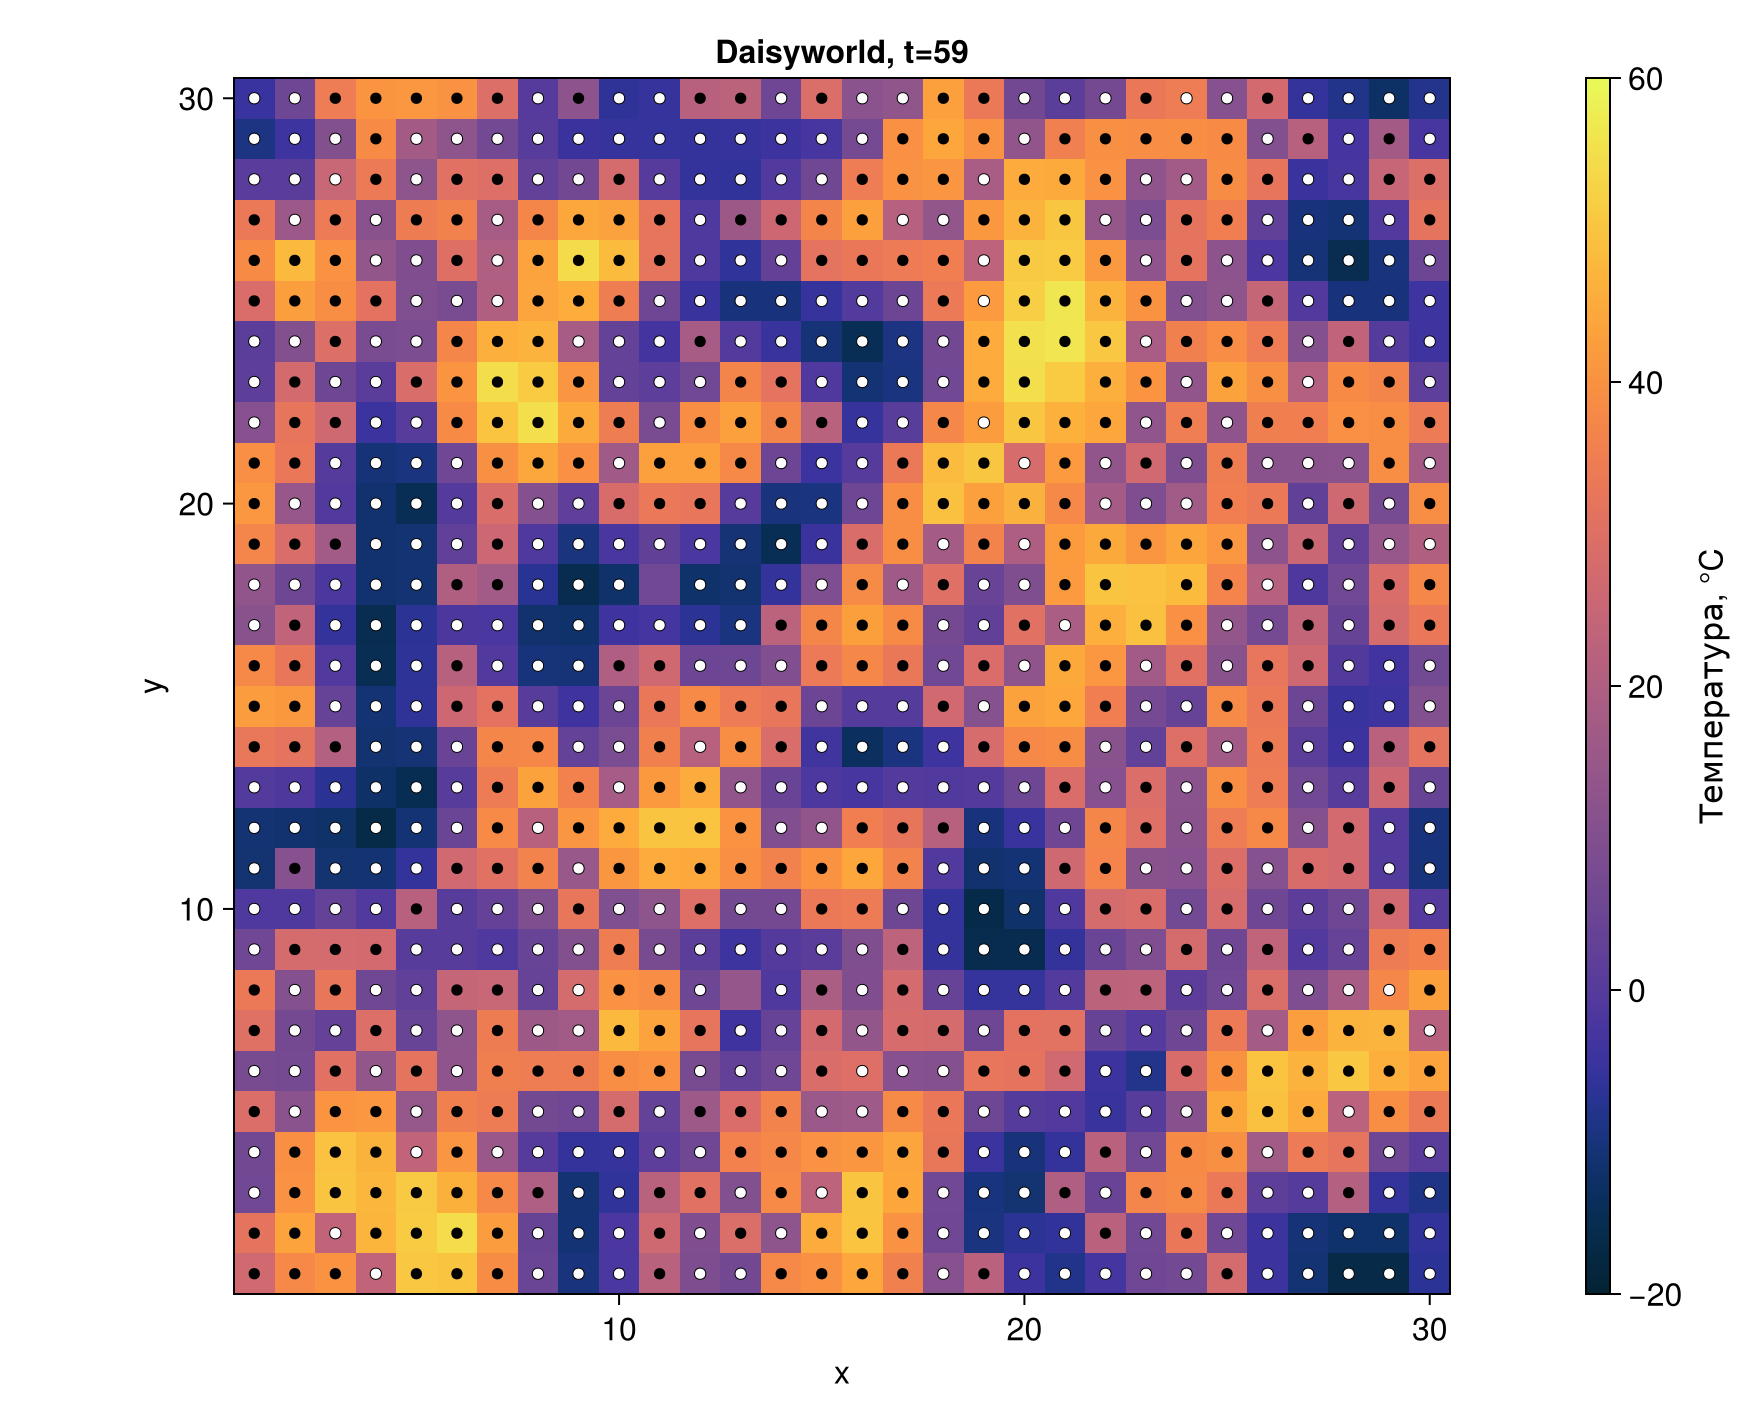

Row,time,black,white,total,empty,temperature,luminosity,albedo,regulation_error
,Int64,Int64,Int64,Int64,Int64,Float64,Float64,Float64,Float64
1,0,180,180,360,540,16.9135,1.0,0.44,5.58646
2,10,459,439,898,2,21.1315,1.0,0.494222,1.36849
3,20,469,431,900,0,21.4456,1.0,0.489444,1.0544
4,30,452,447,899,1,20.7236,1.0,0.4985,1.77641
5,40,471,428,899,1,21.597,1.0,0.487944,0.903004
6,50,462,437,899,1,21.6341,1.0,0.492944,0.865929


In [3]:
frame_data = DataFrame(rows)
CSV.write(scenario_data("daisyworld-animate", "frames.csv"), frame_data)
save(report_figure("animation-final-state.png"), fig)
display(fig)
frame_data[1:10:end, :]